In [1]:
TEST = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/test_balanced'
TRAIN = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/train_balanced'
VAL = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/val_balanced'

We want to use image embeddings for EDA and classification, so let's introduce some code to get image embeddings using ResNeXt without fine-tuning.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 144MB/s]


We have an enormous amount of data, but we're going to start by just loading a small sample.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (48, 48)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    time_get = arrow.now()
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(tqdm.tqdm(list(iglob(pathname=arg)))) if index < 200]
    print('encoded {} rows of {}  in {}'.format(len(result), tag, arrow.now() - time_get))
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder)}
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in train_dict.items()]))
test_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TEST + '/*') if isdir(folder)}
test_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in test_dict.items()]))
val_dict = {basename(folder) : folder + '/*.*' for folder in iglob(VAL + '/*') if isdir(folder)}
val_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in val_dict.items()]))
test_df = pd.concat(axis='index', objs=[test_df, val_df])
print('done in {}'.format(arrow.now() - time_start))

100%|██████████| 6073/6073 [00:32<00:00, 184.72it/s]


encoded 200 rows of DRUSEN  in 0:00:32.977974


100%|██████████| 26080/26080 [00:32<00:00, 804.88it/s]


encoded 200 rows of CNV  in 0:00:32.775031


100%|██████████| 18501/18501 [00:32<00:00, 570.17it/s]


encoded 200 rows of NORMAL  in 0:00:32.677973


100%|██████████| 8043/8043 [00:33<00:00, 241.14it/s]


encoded 200 rows of DME  in 0:00:33.462417


100%|██████████| 1321/1321 [00:34<00:00, 38.01it/s]


encoded 200 rows of DRUSEN  in 0:00:34.787943


100%|██████████| 5614/5614 [00:33<00:00, 165.92it/s]


encoded 200 rows of CNV  in 0:00:33.953576


100%|██████████| 3981/3981 [00:32<00:00, 121.21it/s]


encoded 200 rows of NORMAL  in 0:00:32.905387


100%|██████████| 1734/1734 [00:32<00:00, 53.14it/s]


encoded 200 rows of DME  in 0:00:32.670147


100%|██████████| 1327/1327 [00:32<00:00, 40.59it/s]


encoded 200 rows of DRUSEN  in 0:00:32.728983


100%|██████████| 5616/5616 [00:32<00:00, 170.79it/s]


encoded 200 rows of CNV  in 0:00:32.987535


100%|██████████| 3982/3982 [00:36<00:00, 107.88it/s]


encoded 200 rows of NORMAL  in 0:00:37.125136


100%|██████████| 1737/1737 [00:32<00:00, 52.92it/s]


encoded 200 rows of DME  in 0:00:32.862840
done in 0:06:42.222804


In [4]:
train_df['tag'].value_counts(normalize=True).to_frame().T

tag,DRUSEN,CNV,NORMAL,DME
proportion,0.25,0.25,0.25,0.25


In [5]:
test_df['tag'].value_counts(normalize=True).to_frame().T

tag,DRUSEN,CNV,NORMAL,DME
proportion,0.25,0.25,0.25,0.25


Next let's use TSNE to add x/y coordinates based on our image embeddings.

In [6]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2025, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))
test_reducer = TSNE(random_state=2025, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
test_df[['x', 'y']] = test_reducer.fit_transform(X=test_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 800 samples in 0.005s...
[t-SNE] Computed neighbors for 800 samples in 0.159s...
[t-SNE] Computed conditional probabilities for sample 800 / 800
[t-SNE] Mean sigma: 2.829298
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.011627
[t-SNE] KL divergence after 1000 iterations: 1.561246
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1600 samples in 0.010s...
[t-SNE] Computed neighbors for 1600 samples in 0.341s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1600
[t-SNE] Computed conditional probabilities for sample 1600 / 1600
[t-SNE] Mean sigma: 2.554533
[t-SNE] KL divergence after 250 iterations with early exaggeration: 76.843277
[t-SNE] KL divergence after 1000 iterations: 1.870312


Let's plot.

In [7]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: retinal conditions', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

What do we see? We have a lot of instances where we have more neighbors from the same class than from other classes, but we also have a lot of mixing; we should have modest expectations for our model accuracy. Let's build a model and see what we get.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

logreg = LogisticRegression(max_iter=10000, tol=1e-12).fit(train_df['value'].apply(func=pd.Series), train_df['tag'])
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print(classification_report(zero_division=0.0, y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series))))

model fit in 1179 iterations
accuracy: 0.7456
f1: 0.7457
              precision    recall  f1-score   support

         CNV       0.80      0.72      0.76       400
         DME       0.75      0.77      0.76       400
      DRUSEN       0.67      0.68      0.67       400
      NORMAL       0.77      0.81      0.79       400

    accuracy                           0.75      1600
   macro avg       0.75      0.75      0.75      1600
weighted avg       0.75      0.75      0.75      1600



Our f1 scores are all pretty close to 0.75; it looks like DRUSEN is the toughest class to model. Let's have a look at our model probabilities.

<Axes: xlabel='probability', ylabel='Count'>

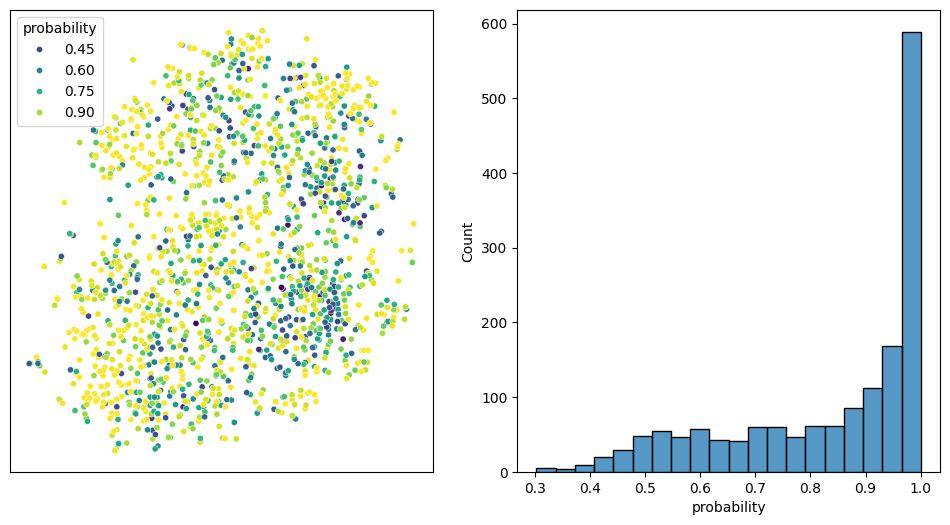

In [9]:
import matplotlib.pyplot as plt
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = test_df[['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=test_df['value'].apply(func=pd.Series)), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=20)
ax[0].set(xlabel=None)
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)

Our training data and test data are disjoint, so we need different TSNE reducers for each, and we get different-looking scatter plots. So it's hard to say which class is producing the lower model probabilities, but from our classification report above we can probably make an educated guess.